# Author: Devendra Nagpure

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import newton

# Material and simulation constants
nu = 0.3
E = 100000  
sigma_0 = E / 500

# Lamé constants
mu = E / (2 * (1 + nu))  # Shear modulus
lambda_prime = E*nu / ((1+nu)* (1- 2 * nu))

# Plasticity parameters
n_values = [0, 0.1]
load_paths = [(-1, 0), (-0.5, -0.5)]

# Deformation range
eps_values = np.linspace(0, 0.05, 10000)

In [2]:

# Deviatoric function
def deviatoric(tensor):
    trace = np.trace(tensor)
    identity = np.identity(3)
    return tensor - (trace / 3) * identity

# Yield stress in term of plastic arc length and n
def yield_stress(s, n):
    return sigma_0 * (1 + 500 * s) ** n



In [3]:
def radial_return(sigma_trail, s, n):
    sigma_trail_dev = deviatoric(sigma_trail)
    sigma_eq_trail = np.sqrt((3/2) * np.sum(sigma_trail_dev**2))
    yield_fun_trail= sigma_eq_trail - yield_stress(s,n)

    if yield_fun_trail<= 0.0:
        return np.zeros((3, 3)), 0.0  # Elastic
    else:
        # Plastic correction
        d_lambda_0=  0

        # Define the function
        def equation(d_lambda):
            eq= yield_fun_trail + yield_stress(s,n) - yield_stress(s+d_lambda,n)- 3*mu*d_lambda
            return eq
        # Solve using Newton-Raphson method
        soln = newton(equation, d_lambda_0)
        d_lambda= soln
        s = s + d_lambda
        C= [1+(3*mu*d_lambda/yield_stress(s,n))] # dividing this with trail deviatoric stress
                                        # gives actual deviatoric stress
        sigma_dev= sigma_trail_dev/ C
        d_eps_p= (3/2)*d_lambda*sigma_dev/ yield_stress(s,n)

        return d_eps_p, s

In [4]:
def run_simulation(a,b,n):
    stresses = []
    plastic_strains = []
    s = 0.0
    sigma= np.zeros((3,3))
    eps_p_total = np.zeros((3, 3))

    for i in range(1, len(eps_values)):
        d_eps_value= eps_values[i]-eps_values[i-1]  # change in strain value
        d_eps = np.array([[1, 0, 0],
                    [0, a, 0],
                    [0, 0, b]]) * d_eps_value  # Change in strain tensor
        
        d_sigma_trail= 2*mu*d_eps + lambda_prime*np.trace(d_eps) * np.eye(3) 
        sigma_trail= sigma + d_sigma_trail

        d_eps_p, s= radial_return(sigma_trail, s, n)
        eps_p_total = eps_p_total+ d_eps_p

        # correcting trail stress to get actual stress
        d_sigma = 2*mu*(d_eps-d_eps_p) + lambda_prime*np.trace(d_eps) * np.eye(3)
        sigma = sigma+ d_sigma

        # stresses.append(sigma)
        # plastic_strains.append(eps_p_total)

        stresses.append([sigma[0, 0], sigma[1, 1], sigma[2, 2]])
        plastic_strains.append([eps_p_total[0, 0], eps_p_total[1, 1], eps_p_total[2, 2]])

    return np.array(stresses), np.array(plastic_strains)



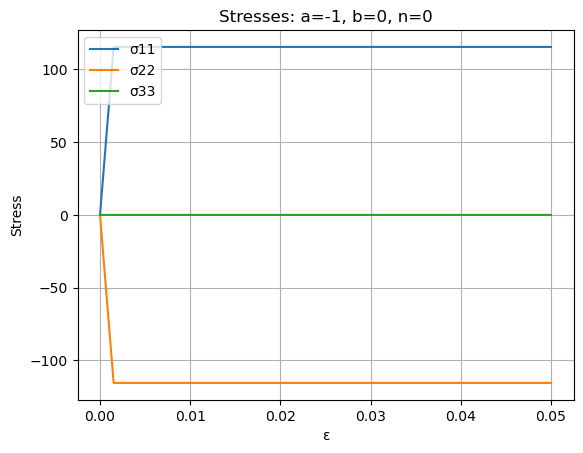

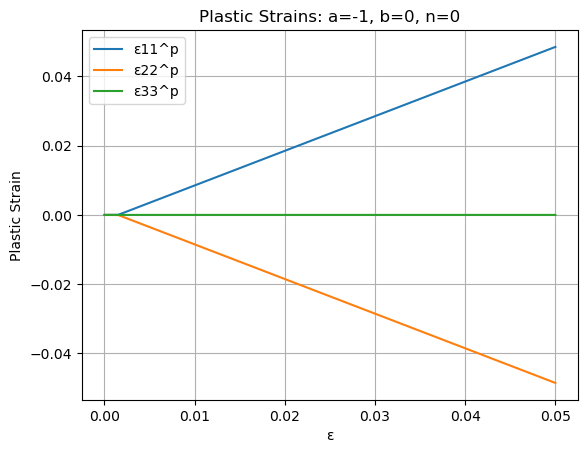

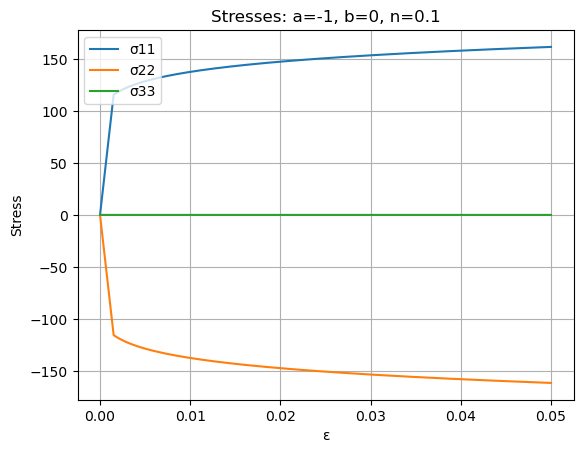

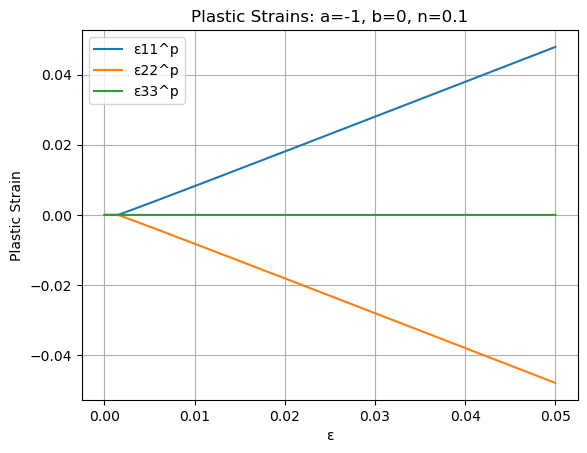

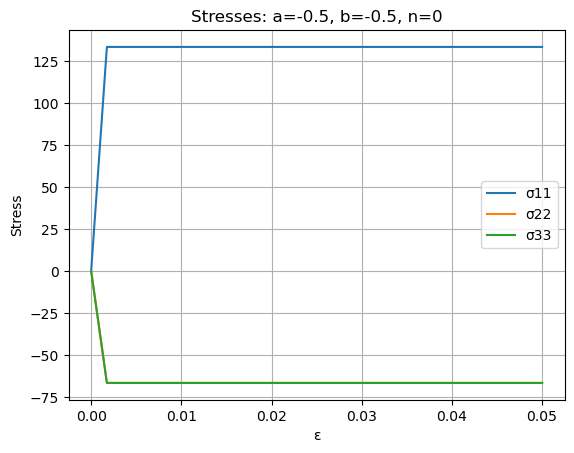

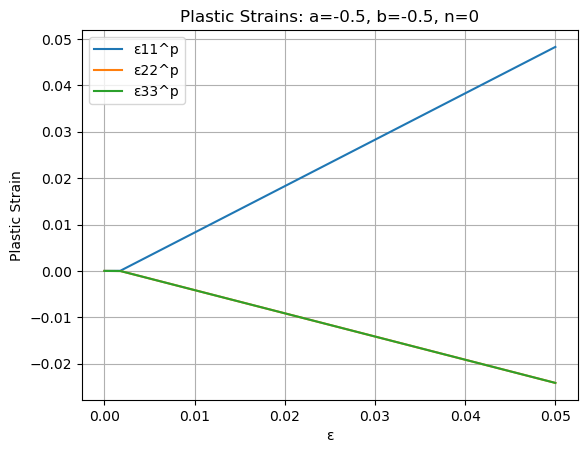

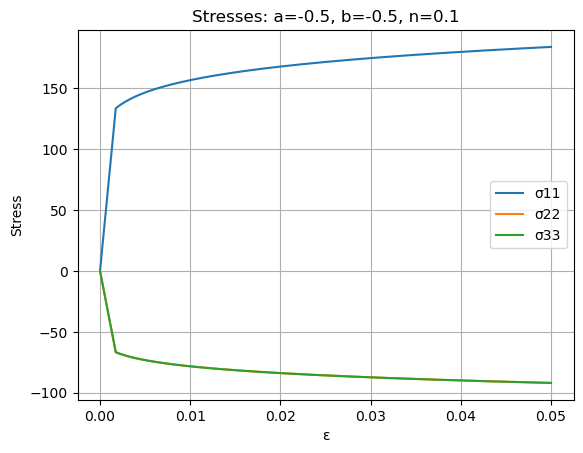

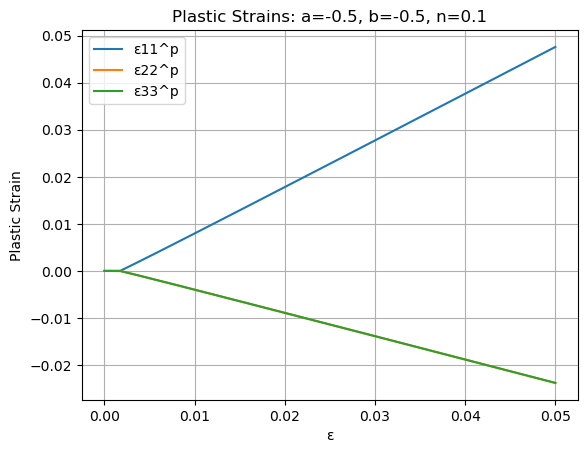

In [5]:
# Plotting
for a, b in load_paths:
    for n in n_values:
        stresses, plastic_strains = run_simulation(a, b, n)
        plt.figure()
        plt.plot(eps_values[1:], stresses[:, 0], label='σ11')
        plt.plot(eps_values[1:], stresses[:, 1], label='σ22')
        plt.plot(eps_values[1:], stresses[:, 2], label='σ33')
        plt.title(f'Stresses: a={a}, b={b}, n={n}')
        plt.xlabel('ε')
        plt.ylabel('Stress')
        plt.legend()
        plt.grid()

        plt.figure()
        plt.plot(eps_values[1:], plastic_strains[:, 0], label='ε11^p')
        plt.plot(eps_values[1:], plastic_strains[:, 1], label='ε22^p')
        plt.plot(eps_values[1:], plastic_strains[:, 2], label='ε33^p')
        plt.title(f'Plastic Strains: a={a}, b={b}, n={n}')
        plt.xlabel('ε')
        plt.ylabel('Plastic Strain')
        plt.legend()
        plt.grid()

plt.show()